# LeetCode #190: Reverse Bits

https://leetcode.com/problems/reverse-bits/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (convert to string, reverse)** | $O(1)$ | $O(1)$ |
| **Optimal: Bit-by-bit Reversal ★** | $O(1)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (convert to string, reverse)
Convert the integer to a zero-padded 32-bit binary string, reverse it, and parse back. Works but involves string allocation and parsing overhead.

### Optimal: Bit-by-bit Reversal ★
In 32 iterations: shift `result` left by 1, OR in the LSB of `n`, then shift `n` right by 1. This moves each bit from LSB-to-MSB position of `n` into MSB-to-LSB position of `result`.

**Why this is better than Brute Force:** Pure integer arithmetic, no string allocation, all operations are $O(1)$ constant-time with a fixed loop of 32 iterations.

**Constraints:**
* The input must be a **binary string** of length 32 (treated as an unsigned 32-bit integer).
* If the function is called many times, you can cache the half-word reversal to speed it up.

## Solutions

### C#

In [ ]:
public uint reverseBits(uint n) {
    uint result = 0;
    for (int i = 0; i < 32; i++) {
        // Shift result left to make room, then OR in the current LSB of n
        result = (result << 1) | (n & 1);
        // Discard the bit we just processed from n
        n >>= 1;
    }
    return result;
}

### Python

In [ ]:
def reverseBits(self, n: int) -> int:
    result = 0
    for _ in range(32):
        # Shift result left, OR in current LSB of n
        result = (result << 1) | (n & 1)
        # Discard the processed LSB of n
        n >>= 1
    return result

### Go

In [ ]:
func reverseBits(num uint32) uint32 {
    var result uint32
    for i := 0; i < 32; i++ {
        // Shift result left, OR in current LSB of num
        result = (result << 1) | (num & 1)
        // Discard the processed LSB
        num >>= 1
    }
    return result
}

### Rust

In [ ]:
pub fn reverse_bits(mut n: u32) -> u32 {
    let mut result = 0u32;
    for _ in 0..32 {
        // Shift result left, OR in current LSB of n
        result = (result << 1) | (n & 1);
        // Discard the processed LSB
        n >>= 1;
    }
    result
}

## Example Scenarios

**1. Common Case**
**Input:** n = 43261596 (binary: 00000010100101000001111010011100)
Reversed bits produce 00111001011110000010100101000000 = **964176192**. Each bit migrates from position $i$ to position $31-i$.

**2. Slightly Complex**
**Input:** n = 4294967293 (binary: 11111111111111111111111111111101, i.e. $2^{32}-3$)
Reversed: 10111111111111111111111111111111 = **3221225471**. Two zero bits at positions 1 and 31 swap to positions 30 and 0.

**3. Edge Case: Time Factor**
**Input:** n = 0 (all bits zero)
All 32 iterations execute; result stays 0 the entire time. Fixed-cost loop: $O(1)$ with exactly 32 iterations regardless of value.

**4. Edge Case: Space Factor**
**Input:** n = 2147483648 ($2^{31}$, i.e. 10000...0 in binary)
Only the MSB is set. After reversal, only the LSB is set → result = 1. Space: two 32-bit registers, constant $O(1)$ regardless of input.

**5. Almost-Impossible but Plausible**
**Input:** n = 4294967295 ($2^{32}-1$, all 32 bits set)
Reversing all-ones gives all-ones: result = **4294967295**. Tests unsigned 32-bit overflow: if signed arithmetic is used by mistake, the sign bit causes incorrect results — must use `uint`/`u32`.

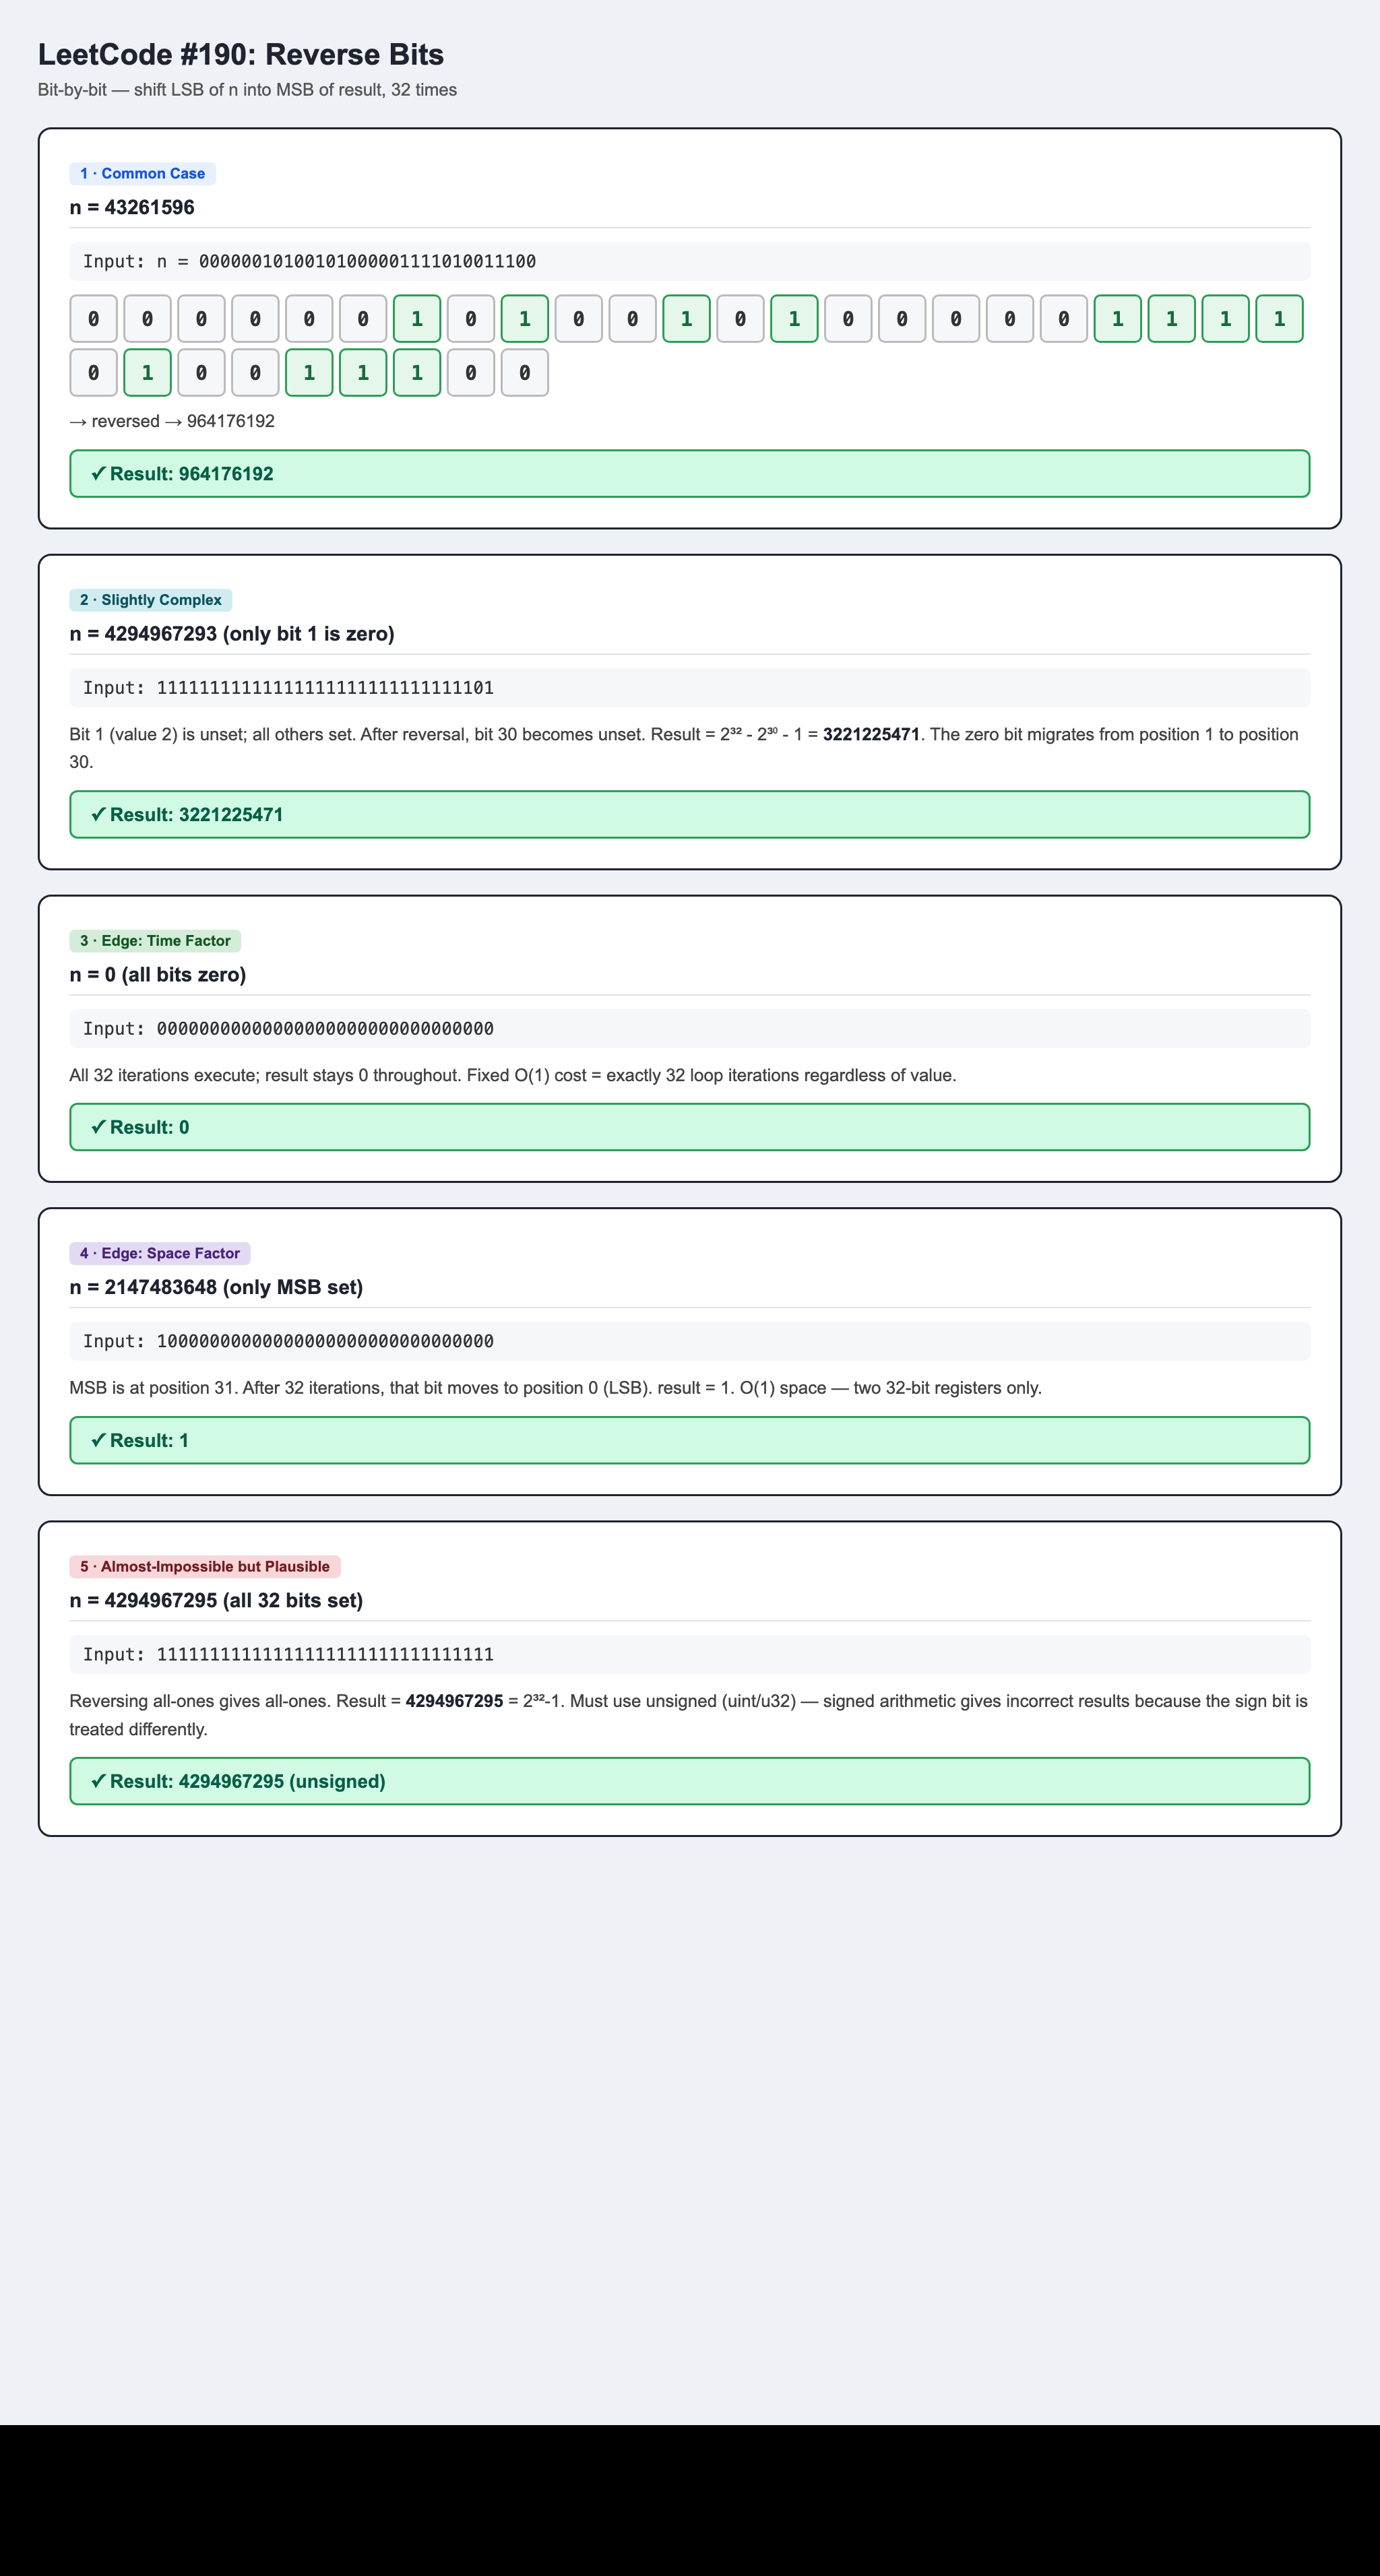